<a href="https://colab.research.google.com/github/gtnothaft/deephedging/blob/main/deep_hedging_replicating_figures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Recreating figure 6 from Buehler et al**: CVaR comparison

the goal of this is to compare hedging strategies under 50% and 99% CVaR optimality citeria, which are different levels of risk aversion that affects both the hedging strategy and the indifference price. Higher risk aversion leads to higher indifference price, better tail protection resulting in lower extreme losses, and is overall more conservative.

---

THe Black-Scholes model is used to simulate stock price paths using geometric Brownian Motion.
---

The terminal P&L is defined as:
$$P\&L = -Z + p_0 +\sum_{k=0}^{n-1}(S_{k+1}-S_k) - \sum_{k=0}^n c|\delta_k-\delta_{k-1}|S_k$$
where $Z$ is the option payoff at maturity, $p_0$ is the initial price charged, and $c$ is the proportional transaction cost rate, which is set to 0 in this case.

---
The deep hedging network architecture is:


*   3 hidden layers with 32 neurons each
*   ReLU activation
*  no position penalty for the 50%-CVaR case, allowing for aggressive hedging
*  Adam optimizer with learning rate of 0.002

---
The risk measure used is the Conditional Value at Risk (CVaR) at level $\alpha$:
$$CVaR_\alpha(X) = \mathbb{E}[X|X\geq VaR_\alpha(X)]$$

the network minimizes
$$L = CVaR_\alpha(-HedgingP\&L)$$
and the indifference price is
$$p(Z) = CVaR_\alpha(-Hedging P\&L)$$



Environment: 30 periods
Training paths: 400000, Test paths: 100000
Risk-neutral price: 2.2872

Training with 50%-CVaR
Training CVaR alpha = 0.5
Position penalty = 0.0
----------------------------------------------------------------------
  epoch   30/300  CVaR: 2.8814  Penalty: 0.0000  Mean Hedging P&L: -2.2776
  epoch   60/300  CVaR: 2.6057  Penalty: 0.0000  Mean Hedging P&L: -2.2744
  epoch   90/300  CVaR: 2.5843  Penalty: 0.0000  Mean Hedging P&L: -2.2758
  epoch  120/300  CVaR: 2.6345  Penalty: 0.0000  Mean Hedging P&L: -2.2971
  epoch  150/300  CVaR: 2.5985  Penalty: 0.0000  Mean Hedging P&L: -2.2773
  epoch  180/300  CVaR: 2.5725  Penalty: 0.0000  Mean Hedging P&L: -2.2818
  epoch  210/300  CVaR: 2.5494  Penalty: 0.0000  Mean Hedging P&L: -2.2816
  epoch  240/300  CVaR: 2.5932  Penalty: 0.0000  Mean Hedging P&L: -2.3169
  epoch  270/300  CVaR: 2.5595  Penalty: 0.0000  Mean Hedging P&L: -2.2652
  epoch  300/300  CVaR: 2.5518  Penalty: 0.0000  Mean Hedging P&L: -2.2747

Training wi

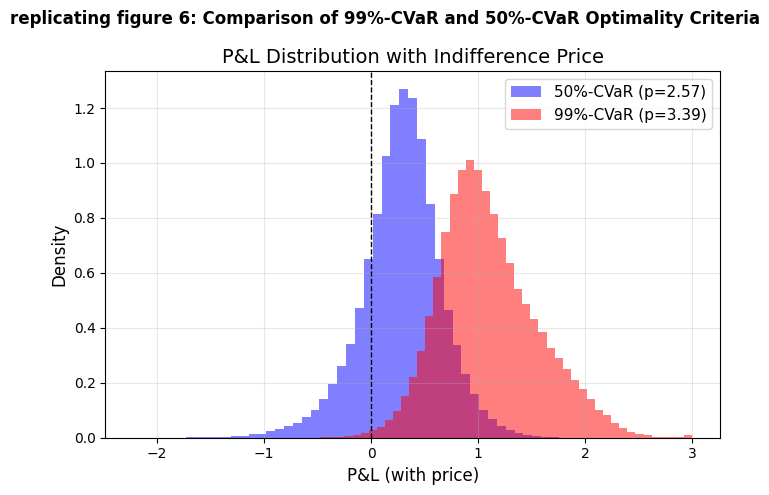


RESULTS SUMMARY
Strategy        Price (CVaR)   Mean Hedge P&L   Mean P&L (w/price) Max |Delta| 
----------------------------------------------------------------------
50%-CVaR            2.5681      -2.2864         0.2817         1.1777
99%-CVaR            3.3864      -2.2878         1.0986         1.6016


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple, Dict
import warnings
warnings.filterwarnings('ignore')

#define BS Model
class BlackScholesModel:
    def __init__(self,
                 S0: float = 100.0,
                 sigma: float = 0.2,
                 r: float = 0.0,
                 T: float = 30/365,
                 n_steps: int = 30,
                 K: float = 100.0):
        self.S0 = S0
        self.sigma = sigma
        self.r = r
        self.T = T
        self.n_steps = n_steps
        self.K = K
        self.dt = T / n_steps

    def simulate_paths(self, n_paths: int, seed: int = None) -> np.ndarray:
        if seed is not None:
            np.random.seed(seed)
        Z = np.random.normal(0, 1, (n_paths, self.n_steps))
        W = np.sqrt(self.dt) * Z
        log_returns = (self.r - 0.5 * self.sigma**2) * self.dt + self.sigma * W
        log_prices = np.zeros((n_paths, self.n_steps + 1))
        log_prices[:, 0] = np.log(self.S0)
        for t in range(self.n_steps):
            log_prices[:, t + 1] = log_prices[:, t] + log_returns[:, t]
        return np.exp(log_prices)

    def get_option_price(self, S: np.ndarray, t: float) -> np.ndarray:
        tau = self.T - t
        if tau <= 0:
            return np.maximum(S - self.K, 0)
        d1 = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * tau) / (self.sigma * np.sqrt(tau))
        d2 = d1 - self.sigma * np.sqrt(tau)
        return S * norm.cdf(d1) - self.K * np.exp(-self.r * tau) * norm.cdf(d2)

    def get_delta(self, S: np.ndarray, t: float) -> np.ndarray:
        tau = self.T - t
        if tau <= 0:
            return (S > self.K).astype(float)
        d1 = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * tau) / (self.sigma * np.sqrt(tau))
        return norm.cdf(d1)

#define hedging environment
class HedgingEnvironment:
    def __init__(self,
                 model: BlackScholesModel,
                 n_train_paths: int = 400000,
                 n_test_paths: int = 100000,
                 transaction_cost: float = 0.0,
                 batch_size: int = 512):
        self.model = model
        self.n_train_paths = n_train_paths
        self.n_test_paths = n_test_paths
        self.transaction_cost = transaction_cost
        self.batch_size = batch_size
        self.n_time_steps = model.n_steps

        self.S_train = model.simulate_paths(n_train_paths, seed=42)
        self.S_test = model.simulate_paths(n_test_paths, seed=123)

        self.Z_train = np.maximum(self.S_train[:, -1] - model.K, 0)
        self.Z_test = np.maximum(self.S_test[:, -1] - model.K, 0)

        self.risk_neutral_price = model.get_option_price(model.S0, 0)

        self.features_train = self._create_features(self.S_train)
        self.features_test = self._create_features(self.S_test)

        self.feat_mean = np.mean(self.features_train, axis=(0, 1), keepdims=True)
        self.feat_std = np.std(self.features_train, axis=(0, 1), keepdims=True) + 1e-8
        self.features_train = (self.features_train - self.feat_mean) / self.feat_std
        self.features_test = (self.features_test - self.feat_mean) / self.feat_std

        self.delta_test = self._compute_deltas(self.S_test)

        print(f"Environment: {self.n_time_steps} periods")
        print(f"Training paths: {self.S_train.shape[0]}, Test paths: {self.S_test.shape[0]}")
        print(f"Risk-neutral price: {self.risk_neutral_price:.4f}")

    def _create_features(self, S: np.ndarray) -> np.ndarray:
        n_paths, n_steps = S.shape
        features = np.zeros((n_paths, n_steps - 1, 2))
        for t in range(n_steps - 1):
            time_remaining = self.model.T - t * self.model.dt
            features[:, t, 0] = np.log(S[:, t] / self.model.K)
            features[:, t, 1] = time_remaining / self.model.T
        return features

    def _compute_deltas(self, S: np.ndarray) -> np.ndarray:
        n_paths, n_steps = S.shape
        deltas = np.zeros((n_paths, n_steps - 1))
        for t in range(n_steps - 1):
            time = t * self.model.dt
            deltas[:, t] = self.model.get_delta(S[:, t], time)
        return deltas

    def create_batch(self) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        indices = np.random.choice(self.n_train_paths, self.batch_size, replace=False)
        return (tf.convert_to_tensor(self.features_train[indices], dtype=tf.float32),tf.convert_to_tensor(self.Z_train[indices], dtype=tf.float32),tf.convert_to_tensor(self.S_train[indices], dtype=tf.float32))

    def compute_hedging_pnl(self, deltas: np.ndarray, S: np.ndarray, Z: np.ndarray) -> np.ndarray:
        n_paths = deltas.shape[0]
        n_periods = deltas.shape[1]

        trading_pnl = np.zeros(n_paths)
        for k in range(n_periods):
            trading_pnl += deltas[:, k] * (S[:, k + 1] - S[:, k])

        transaction_costs = np.zeros(n_paths)
        for k in range(n_periods):
            if k == 0:
                delta_change = deltas[:, k]
            else:
                delta_change = deltas[:, k] - deltas[:, k - 1]
            transaction_costs += self.transaction_cost * np.abs(delta_change) * S[:, k]

        return -Z + trading_pnl - transaction_costs

    def compute_pnl_with_price(self, deltas: np.ndarray, S: np.ndarray, Z: np.ndarray, price: float) -> np.ndarray:
        return price + self.compute_hedging_pnl(deltas, S, Z)

#define deep hedging network
class DeepHedgingNetwork(keras.Model):
    def __init__(self, n_features: int = 2, hidden_dim: int = 32, n_time_steps: int = 30):
        super().__init__()
        self.n_time_steps = n_time_steps
        self.dense1 = layers.Dense(hidden_dim, activation='relu')
        self.dense2 = layers.Dense(hidden_dim, activation='relu')
        self.dense3 = layers.Dense(hidden_dim, activation='relu')
        self.dense4 = layers.Dense(1)

    def call(self, features, training=False):
        batch_size = tf.shape(features)[0]
        n_steps = features.shape[1]
        n_features = features.shape[2]

        x = tf.reshape(features, (-1, n_features))
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        x = tf.reshape(x, (batch_size, n_steps, 1))
        return tf.squeeze(x, axis=-1)

    def forward(self, features: np.ndarray) -> np.ndarray:
        return self(features, training=False).numpy()

#define trainer
class DeepHedgingTrainer:
    def __init__(self, env: HedgingEnvironment,network: DeepHedgingNetwork, cvar_alpha: float = 0.5, position_penalty: float = 0.0):
        self.env = env
        self.network = network
        self.cvar_alpha = cvar_alpha
        self.position_penalty = position_penalty
        self.optimizer = keras.optimizers.Adam(learning_rate=0.002)

        self.history = {'loss': [], 'cvar': [], 'mean_pnl': [], 'penalty': []}

    def train_step(self, features_batch: tf.Tensor, Z_batch: tf.Tensor,
                   S_batch: tf.Tensor) -> Dict:
        n_paths = features_batch.shape[0]
        n_steps = features_batch.shape[1]

        with tf.GradientTape() as tape:
            deltas = self.network(features_batch, training=True)
            dS = S_batch[:, 1:] - S_batch[:, :-1]

            hedging_pnl = -Z_batch + tf.reduce_sum(deltas * dS, axis=1)

            if self.env.transaction_cost > 0:
                delta_prev = tf.concat([tf.zeros((n_paths, 1)), deltas[:, :-1]], axis=1)
                delta_change = deltas - delta_prev
                costs = self.env.transaction_cost * tf.reduce_sum(tf.abs(delta_change) * S_batch[:, :-1], axis=1)
                hedging_pnl = hedging_pnl - costs

            losses = -hedging_pnl
            k = tf.cast((1.0 - self.cvar_alpha) * tf.cast(n_paths, tf.float32), tf.int32)
            k = tf.maximum(k, 1)
            top_losses, _ = tf.nn.top_k(losses, k)
            cvar = tf.reduce_mean(top_losses)

            penalty = self.position_penalty * tf.reduce_mean(tf.square(deltas))
            loss = cvar + penalty

        grads = tape.gradient(loss, self.network.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.network.trainable_variables))

        return {
            'loss': loss.numpy(),
            'cvar': cvar.numpy(),
            'penalty': penalty.numpy(),
            'mean_hedging_pnl': tf.reduce_mean(hedging_pnl).numpy()
        }

    def train(self, n_epochs: int = 300, verbose: bool = True):
        print(f"Training CVaR alpha = {self.cvar_alpha}")
        print(f"Position penalty = {self.position_penalty}")
        print("-" * 70)

        for epoch in range(n_epochs):
            features_batch, Z_batch, S_batch = self.env.create_batch()
            results = self.train_step(features_batch, Z_batch, S_batch)

            self.history['loss'].append(results['loss'])
            self.history['cvar'].append(results['cvar'])
            self.history['penalty'].append(results['penalty'])
            self.history['mean_pnl'].append(results['mean_hedging_pnl'])

            if verbose and (epoch + 1) % 30 == 0:
                print(f"  epoch {epoch+1:4d}/{n_epochs}  "
                      f"CVaR: {results['cvar']:.4f}  "
                      f"Penalty: {results['penalty']:.4f}  "
                      f"Mean Hedging P&L: {results['mean_hedging_pnl']:.4f}")

    def evaluate(self) -> Dict:
        deltas = self.network.forward(self.env.features_test)
        hedging_pnl = self.env.compute_hedging_pnl(deltas, self.env.S_test, self.env.Z_test)

        losses = -hedging_pnl
        sorted_losses = np.sort(losses)
        idx = int(len(sorted_losses) * self.cvar_alpha)
        price = np.mean(sorted_losses[idx:])

        return {
            'deltas': deltas,
            'hedging_pnl': hedging_pnl,
            'pnl_with_price': hedging_pnl + price,
            'price': price,
            'mean_hedging_pnl': np.mean(hedging_pnl),
            'std_hedging_pnl': np.std(hedging_pnl),
            'mean_pnl_with_price': np.mean(hedging_pnl + price),
            'std_pnl_with_price': np.std(hedging_pnl + price),
            'max_delta': np.max(np.abs(deltas))
        }



def run_experiment():
    model = BlackScholesModel(
        S0=100.0,
        sigma=0.2,
        r=0.0,
        T=30/365,
        n_steps=30,
        K=100.0)

    env = HedgingEnvironment(
        model=model,
        n_train_paths=400000,
        n_test_paths=100000,
        transaction_cost=0.0,
        batch_size=512)

    results = {}

    # NO penalty for 50%-CVaR, small penalty for 99%-CVaR
    penalty_config = {0.5: 0.0,0.99: 0.005}

    for alpha in [0.5,0.99]:
        print(f"\n{'='*60}")
        print(f"Training with {alpha*100:.0f}%-CVaR")
        print(f"{'='*60}")

        network = DeepHedgingNetwork(n_features=2,hidden_dim=32,n_time_steps=env.n_time_steps)
        trainer = DeepHedgingTrainer(env=env,network=network,cvar_alpha=alpha, position_penalty=penalty_config[alpha])
        trainer.train(n_epochs=300, verbose=True)
        eval_results = trainer.evaluate()
        results[f"{alpha*100:.0f}%-CVaR"] = eval_results

    plot_figure6(results)

    print("\n" + "=" * 70)
    print("RESULTS SUMMARY")
    print("=" * 70)
    print(f"{'Strategy':<15} {'Price (CVaR)':<14} {'Mean Hedge P&L':<16} {'Mean P&L (w/price)':<18} {'Max |Delta|':<12}")
    print("-" * 70)
    for label, data in results.items():
        print(f"{label:<15} {data['price']:>10.4f}   {data['mean_hedging_pnl']:>10.4f}     {data['mean_pnl_with_price']:>10.4f}     {data['max_delta']:>10.4f}")
    return results


def plot_figure6(results):
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    ax1 = axes
    colors = {'50%-CVaR': 'blue', '99%-CVaR': 'red'}
    labels = {'50%-CVaR': f"50%-CVaR (p={results['50%-CVaR']['price']:.2f})",
              '99%-CVaR': f"99%-CVaR (p={results['99%-CVaR']['price']:.2f})"}
    for label, data in results.items():
        pnl = data['pnl_with_price']
        pnl_clipped = np.clip(pnl, -3, 3)
        ax1.hist(pnl_clipped, bins=50, alpha=0.5,
                label=labels[label], color=colors[label], density=True)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlabel('P&L (with price)', fontsize=12)
    ax1.set_ylabel('Density', fontsize=12)
    ax1.set_title('P&L Distribution with Indifference Price', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)



    plt.suptitle('replicating figure 6: Comparison of 99%-CVaR and 50%-CVaR Optimality Criteria', fontweight='bold')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    results = run_experiment()

This shows that tail protection comes at a cost, with protection against extreme loss coming from the higher price. The mean hedging p&l is very similar, and the difference comes from the tail behavior.

---

**Replicating Figure 5 from Buehler et al**: Recurrent vs Simple network structure

The recurrent network remembers the previous position, compared to the simple network that only sees the current market information.

Decision rule for simple network: $\delta_k = F^{\theta_k}(I_k)$

Decision rule for recurrent network:$\delta_k = F^{\theta_k}(I_k,\delta_{k-1})$



---



Like above, the market model is simulated using the Black-Scholes model.


---

The terminal P&L is defined as:
$$P\&L = -Z + p_0 +\sum_{k=0}^{n-1}(S_{k+1}-S_k) - \sum_{k=0}^n c|\delta_k-\delta_{k-1}|S_k$$
where $Z$ is the option payoff at maturity, $p_0$ is the initial price charged, and $c$ is the proportional transaction cost rate.



---

The architecture of the networks, as defined in the paper:


*   2 hidden layers
*   16 neurons per layer (15+1, where there is one hedging instrument being used)
*   ReLU activation
*   Adam optimizer with learning rate 0.005


---

The risk measure used is the Conditional Value at Risk (CVaR) at level $\alpha$:
$$CVaR_\alpha(X) = \mathbb{E}[X|X\geq VaR_\alpha(X)]$$

the network minimizes
$$L = CVaR_\alpha(-HedgingP\&L)$$
and the indifference price is
$$p(Z) = CVaR_\alpha(-Hedging P\&L)$$






Environment: 30 periods
Training paths: 400000, Test paths: 100000
Transaction cost: 1.0%
Risk-neutral price: 2.2872

Simple Network
Training CVaR alpha = 0.99
Learning rate = 0.0010
----------------------------------------------------------------------
  epoch   50/400  CVaR: 8.2297  Mean P&L: -3.6036  Mean Cost: 1.4668
  epoch  100/400  CVaR: 6.7956  Mean P&L: -4.0785  Mean Cost: 1.7841
  epoch  150/400  CVaR: 6.1128  Mean P&L: -3.9669  Mean Cost: 1.7336
  epoch  200/400  CVaR: 5.4746  Mean P&L: -3.9732  Mean Cost: 1.6598
  epoch  250/400  CVaR: 5.6163  Mean P&L: -3.9141  Mean Cost: 1.6249
  epoch  300/400  CVaR: 5.3919  Mean P&L: -3.9372  Mean Cost: 1.6858
  epoch  350/400  CVaR: 5.7287  Mean P&L: -3.8799  Mean Cost: 1.6562
  epoch  400/400  CVaR: 5.4351  Mean P&L: -3.9259  Mean Cost: 1.6283

Recurrent Network
Training CVaR alpha = 0.99
Learning rate = 0.0010
----------------------------------------------------------------------
  epoch   50/600  CVaR: 7.8726  Mean P&L: -4.0670  Mea

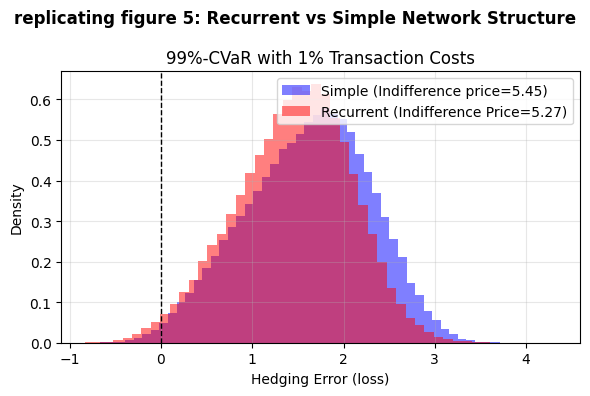

results summary 
Network         Indiff Price   Mean Loss (RN)   Mean Cost    Max |Delta| 
----------------------------------------------------------------------
Simple              5.4549       1.6075           1.6027         1.2175
Recurrent           5.2719       1.4528           1.4492         1.2706


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple, Dict
import warnings
warnings.filterwarnings('ignore')


class BlackScholesModel:
    def __init__(self,
                 S0: float = 100.0,
                 sigma: float = 0.2,
                 r: float = 0.0,
                 T: float = 30/365,
                 n_steps: int = 30,
                 K: float = 100.0):
        self.S0 = S0
        self.sigma = sigma
        self.r = r
        self.T = T
        self.n_steps = n_steps
        self.K = K
        self.dt = T / n_steps

    def simulate_paths(self, n_paths: int, seed: int = None) -> np.ndarray:
        if seed is not None:
            np.random.seed(seed)
        Z = np.random.normal(0, 1, (n_paths, self.n_steps))
        W = np.sqrt(self.dt) * Z
        log_returns = (self.r - 0.5 * self.sigma**2) * self.dt + self.sigma * W
        log_prices = np.zeros((n_paths, self.n_steps + 1))
        log_prices[:, 0] = np.log(self.S0)
        for t in range(self.n_steps):
            log_prices[:, t + 1] = log_prices[:, t] + log_returns[:, t]
        return np.exp(log_prices)

    def get_option_price(self, S: np.ndarray, t: float) -> np.ndarray:
        tau = self.T - t
        if tau <= 0:
            return np.maximum(S - self.K, 0)
        d1 = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * tau) / (self.sigma * np.sqrt(tau))
        d2 = d1 - self.sigma * np.sqrt(tau)
        return S * norm.cdf(d1) - self.K * np.exp(-self.r * tau) * norm.cdf(d2)

    def get_delta(self, S: np.ndarray, t: float) -> np.ndarray:
        tau = self.T - t
        if tau <= 0:
            return (S > self.K).astype(float)
        d1 = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * tau) / (self.sigma * np.sqrt(tau))
        return norm.cdf(d1)


class HedgingEnvironment:
    def __init__(self,
                 model: BlackScholesModel,
                 n_train_paths: int = 400000,
                 n_test_paths: int = 100000,
                 transaction_cost: float = 0.01,
                 batch_size: int = 256):
        self.model = model
        self.n_train_paths = n_train_paths
        self.n_test_paths = n_test_paths
        self.transaction_cost = transaction_cost
        self.batch_size = batch_size
        self.n_time_steps = model.n_steps

        self.S_train = model.simulate_paths(n_train_paths, seed=42)
        self.S_test = model.simulate_paths(n_test_paths, seed=123)

        self.Z_train = np.maximum(self.S_train[:, -1] - model.K, 0)
        self.Z_test = np.maximum(self.S_test[:, -1] - model.K, 0)

        self.risk_neutral_price = model.get_option_price(model.S0, 0)

        self.features_train = self._create_features(self.S_train)
        self.features_test = self._create_features(self.S_test)

        self.feat_mean = np.mean(self.features_train, axis=(0, 1), keepdims=True)
        self.feat_std = np.std(self.features_train, axis=(0, 1), keepdims=True) + 1e-8
        self.features_train = (self.features_train - self.feat_mean) / self.feat_std
        self.features_test = (self.features_test - self.feat_mean) / self.feat_std

        print(f"Environment: {self.n_time_steps} periods")
        print(f"Training paths: {self.S_train.shape[0]}, Test paths: {self.S_test.shape[0]}")
        print(f"Transaction cost: {self.transaction_cost*100:.1f}%")
        print(f"Risk-neutral price: {self.risk_neutral_price:.4f}")

    def _create_features(self, S: np.ndarray) -> np.ndarray:
        n_paths, n_steps = S.shape
        features = np.zeros((n_paths, n_steps - 1, 2))
        for t in range(n_steps - 1):
            time_remaining = self.model.T - t * self.model.dt
            features[:, t, 0] = np.log(S[:, t] / self.model.K)
            features[:, t, 1] = time_remaining / self.model.T
        return features

    def create_batch(self) -> Tuple[tf.Tensor, tf.Tensor, tf.Tensor]:
        indices = np.random.choice(self.n_train_paths, self.batch_size, replace=False)
        return (tf.convert_to_tensor(self.features_train[indices], dtype=tf.float32),
                tf.convert_to_tensor(self.Z_train[indices], dtype=tf.float32),
                tf.convert_to_tensor(self.S_train[indices], dtype=tf.float32))

    def compute_hedging_pnl_and_cost(self, deltas: np.ndarray, S: np.ndarray, Z: np.ndarray):
        n_paths = deltas.shape[0]
        n_periods = deltas.shape[1]

        trading_pnl = np.zeros(n_paths)
        for k in range(n_periods):
            trading_pnl += deltas[:, k] * (S[:, k + 1] - S[:, k])

        transaction_costs = np.zeros(n_paths)
        for k in range(n_periods):
            if k == 0:
                delta_change = deltas[:, k]
            else:
                delta_change = deltas[:, k] - deltas[:, k - 1]
            transaction_costs += self.transaction_cost * np.abs(delta_change) * S[:, k]

        hedging_pnl = -Z + trading_pnl - transaction_costs
        return hedging_pnl, transaction_costs

    def compute_pnl_with_price(self, deltas: np.ndarray, S: np.ndarray, Z: np.ndarray, price: float) -> np.ndarray:
        hedging_pnl, _ = self.compute_hedging_pnl_and_cost(deltas, S, Z)
        return price + hedging_pnl


#simple network definition
class SimpleNetwork(keras.Model):

    def __init__(self, n_features: int = 2, hidden_dim: int = 16, n_time_steps: int = 30):
        super().__init__()
        self.n_time_steps = n_time_steps
        self.dense1 = layers.Dense(hidden_dim, activation='relu')
        self.dense2 = layers.Dense(hidden_dim, activation='relu')
        self.dense3 = layers.Dense(1)

    def call(self, features, training=False):
        batch_size = tf.shape(features)[0]
        n_steps = features.shape[1]
        n_features = features.shape[2]

        x = tf.reshape(features, (-1, n_features))
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.dense3(x)
        x = tf.reshape(x, (batch_size, n_steps, 1))
        return tf.squeeze(x, axis=-1)

    def forward(self, features: np.ndarray) -> np.ndarray:
        return self(features, training=False).numpy()

#recurrent network definition
class RecurrentNetwork(keras.Model):

    def __init__(self, n_features: int = 2, hidden_dim: int = 16, n_time_steps: int = 30):
        super().__init__()
        self.n_time_steps = n_time_steps
        self.dense1 = layers.Dense(hidden_dim, activation='relu')
        self.dense2 = layers.Dense(hidden_dim, activation='relu')
        self.dense3 = layers.Dense(1)

    def call(self, features, training=False):
        batch_size = tf.shape(features)[0]
        n_steps = features.shape[1]
        n_features = features.shape[2]

        deltas_list = []
        delta_prev = tf.zeros((batch_size, 1))

        for k in range(n_steps):
            feat_k = features[:, k, :]
            inputs = tf.concat([feat_k, delta_prev], axis=1)

            x = self.dense1(inputs)
            x = self.dense2(x)
            delta_k = self.dense3(x)

            deltas_list.append(delta_k)
            delta_prev = delta_k

        deltas = tf.concat(deltas_list, axis=1)
        return deltas

    def forward(self, features: np.ndarray) -> np.ndarray:
        return self(features, training=False).numpy()

#trainer for deep hedging
class DeepHedgingTrainer:
    def __init__(self,
                 env: HedgingEnvironment,
                 network: keras.Model,
                 cvar_alpha: float = 0.99,
                 learning_rate: float = 0.005):
        self.env = env
        self.network = network
        self.cvar_alpha = cvar_alpha
        self.optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

        self.history = {'loss': [], 'cvar': [], 'mean_pnl': [], 'mean_cost': []}

    def train_step(self, features_batch: tf.Tensor, Z_batch: tf.Tensor,S_batch: tf.Tensor) -> Dict:
        n_paths = features_batch.shape[0]
        n_steps = features_batch.shape[1]

        with tf.GradientTape() as tape:
            deltas = self.network(features_batch, training=True)

            dS = S_batch[:, 1:] - S_batch[:, :-1]

            delta_prev = tf.concat([tf.zeros((n_paths, 1)), deltas[:, :-1]], axis=1)
            delta_change = deltas - delta_prev
            costs = self.env.transaction_cost * tf.reduce_sum(tf.abs(delta_change) * S_batch[:, :-1], axis=1)

            hedging_pnl = -Z_batch + tf.reduce_sum(deltas * dS, axis=1) - costs

            losses = -hedging_pnl
            k = tf.cast((1.0 - self.cvar_alpha) * tf.cast(n_paths, tf.float32), tf.int32)
            k = tf.maximum(k, 1)
            top_losses, _ = tf.nn.top_k(losses, k)
            cvar = tf.reduce_mean(top_losses)

            loss = cvar

        grads = tape.gradient(loss, self.network.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.network.trainable_variables))

        return {'loss': loss.numpy(), 'cvar': cvar.numpy(), 'mean_pnl': tf.reduce_mean(hedging_pnl).numpy(),'mean_cost': tf.reduce_mean(costs).numpy()}

    def train(self, n_epochs: int = 200, verbose: bool = True):
        print(f"Training CVaR alpha = {self.cvar_alpha}")
        print(f"Learning rate = {self.optimizer.learning_rate.numpy():.4f}")
        print("-" * 70)

        for epoch in range(n_epochs):
            features_batch, Z_batch, S_batch = self.env.create_batch()
            results = self.train_step(features_batch, Z_batch, S_batch)

            self.history['loss'].append(results['loss'])
            self.history['cvar'].append(results['cvar'])
            self.history['mean_pnl'].append(results['mean_pnl'])
            self.history['mean_cost'].append(results['mean_cost'])

            if verbose and (epoch + 1) % 50 == 0: #keep track of evolution
                print(f"  epoch {epoch+1:4d}/{n_epochs}  "
                      f"CVaR: {results['cvar']:.4f}  "
                      f"Mean P&L: {results['mean_pnl']:.4f}  "
                      f"Mean Cost: {results['mean_cost']:.4f}")

    def evaluate(self) -> Dict:
        deltas = self.network.forward(self.env.features_test)
        hedging_pnl, costs = self.env.compute_hedging_pnl_and_cost(deltas, self.env.S_test, self.env.Z_test)

        losses = -hedging_pnl
        sorted_losses = np.sort(losses)
        idx = int(len(sorted_losses) * self.cvar_alpha)
        indifference_price = np.mean(sorted_losses[idx:])

        hedging_error_rn = self.env.compute_pnl_with_price(deltas, self.env.S_test, self.env.Z_test, self.env.risk_neutral_price)

        pnl_with_price = self.env.compute_pnl_with_price(deltas, self.env.S_test, self.env.Z_test, indifference_price)

        return {
            'deltas': deltas,
            'hedging_pnl': hedging_pnl,
            'hedging_error_rn': hedging_error_rn,
            'pnl_with_price': pnl_with_price,
            'indifference_price': indifference_price,
            'mean_hedging_pnl': np.mean(hedging_pnl),
            'std_hedging_pnl': np.std(hedging_pnl),
            'mean_hedging_error_rn': np.mean(hedging_error_rn),
            'std_hedging_error_rn': np.std(hedging_error_rn),
            'mean_pnl_with_price': np.mean(pnl_with_price),
            'std_pnl_with_price': np.std(pnl_with_price),
            'mean_cost': np.mean(costs),
            'std_cost': np.std(costs),
            'max_delta': np.max(np.abs(deltas))
        }

def run_figure5():

    model = BlackScholesModel(
        S0=100.0,
        sigma=0.2,
        r=0.0,
        T=30/365,
        n_steps=30,
        K=100.0
    )

    env = HedgingEnvironment(
        model=model,
        n_train_paths=400000,
        n_test_paths=100000,
        transaction_cost=0.01,
        batch_size=512
    )

    results = {}

    print(f"\n{'='*60}")
    print("Simple Network")
    print(f"{'='*60}")

    simple_network = SimpleNetwork( n_features=2, hidden_dim=16, n_time_steps=env.n_time_steps)
    simple_trainer = DeepHedgingTrainer(env=env,network=simple_network,cvar_alpha=0.99,learning_rate=0.001)

    simple_trainer.train(n_epochs=400, verbose=True)
    simple_results = simple_trainer.evaluate()
    results['Simple'] = simple_results

    print(f"\n{'='*60}")
    print("Recurrent Network")
    print(f"{'='*60}")

    recurrent_network = RecurrentNetwork(n_features=2, hidden_dim=16, n_time_steps=env.n_time_steps)

    recurrent_trainer = DeepHedgingTrainer(env=env,network=recurrent_network,cvar_alpha=0.99,learning_rate=0.001)

    recurrent_trainer.train(n_epochs=600, verbose=True)
    recurrent_results = recurrent_trainer.evaluate()
    results['Recurrent'] = recurrent_results

    plot_figure5(results, env)


    print("results summary ")
    print("=" * 70)
    print(f"{'Network':<15} {'Indiff Price':<14} {'Mean Loss (RN)':<16} {'Mean Cost':<12} {'Max |Delta|':<12}")
    print("-" * 70)

    for label, data in results.items():
        mean_loss = -data['mean_hedging_error_rn']
        print(f"{label:<15} {data['indifference_price']:>10.4f}   {mean_loss:>10.4f}       {data['mean_cost']:>10.4f}     {data['max_delta']:>10.4f}")

    return results


def plot_figure5(results, env):
    fig, ax = plt.subplots(1, 1, figsize=(6,4))
    ax1 = ax
    colors = {'Simple': 'blue', 'Recurrent': 'red'}
    labels = {'Simple': f"Simple (Indifference price={results['Simple']['indifference_price']:.2f})",'Recurrent': f"Recurrent (Indifference Price={results['Recurrent']['indifference_price']:.2f})"}

    for label, data in results.items():
        loss = -data['hedging_error_rn']
        ax1.hist(loss, bins=50, alpha=0.5, label=labels[label], color=colors[label], density=True)

    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.set_xlabel('Hedging Error (loss)')
    ax1.set_ylabel('Density')
    ax1.set_title('99%-CVaR with 1% Transaction Costs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)


    plt.suptitle('replicating figure 5: Recurrent vs Simple Network Structure', fontweight='bold')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    results = run_figure5()

here we can see that the recurrent network outperforms the simple network where using transaction costs. This shows that position memory does indeed matter, since it can reduce unnecessary trading. The recurrent network shows lower indifference price, lower mean loss, and lower mean cost.